In [24]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display


import torch
from src.mlconfgen.cheminformatics.shape_similarity import rotate_coord, tanimoto_score

MIN_SIZE_DEFAULT = 6
MAX_SIZE_DEFAULT = 20

def find_cuttable_bonds(mol):
    """Single, non-ring bonds only."""
    cuttable = []
    for bond in mol.GetBonds():
        if bond.IsInRing():
            continue
        if bond.GetBondType() != Chem.BondType.SINGLE:
            continue
        cuttable.append(bond.GetIdx())
    return cuttable


def _build_fragment_adjacency(mol, fragments):
    atom_to_frag = {}
    for fi, atom_set in enumerate(fragments):
        for idx in atom_set:
            atom_to_frag[idx] = fi

    adj = {i: set() for i in range(len(fragments))}
    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        if a1 not in atom_to_frag or a2 not in atom_to_frag:
            continue
        f1 = atom_to_frag[a1]
        f2 = atom_to_frag[a2]
        if f1 != f2:
            adj[f1].add(f2)
            adj[f2].add(f1)
    return adj


def _components_after_cut(mol, atom_set, cut_bond_idx):
    bond = mol.GetBondWithIdx(cut_bond_idx)
    a_rm1 = bond.GetBeginAtomIdx()
    a_rm2 = bond.GetEndAtomIdx()

    local_adj = {a: set() for a in atom_set}
    for b in mol.GetBonds():
        a1 = b.GetBeginAtomIdx()
        a2 = b.GetEndAtomIdx()
        if a1 not in atom_set or a2 not in atom_set:
            continue
        if b.GetIdx() == cut_bond_idx:
            continue
        local_adj[a1].add(a2)
        local_adj[a2].add(a1)

    seen = set()
    comps = []
    for a in atom_set:
        if a in seen:
            continue
        stack = [a]
        comp = set()
        while stack:
            x = stack.pop()
            if x in seen:
                continue
            seen.add(x)
            comp.add(x)
            stack.extend(local_adj[x] - seen)
        comps.append(comp)

    return comps


def _try_merge_small_fragment(mol, fragments, min_size, max_size):
    sizes = [len(s) for s in fragments]
    adj = _build_fragment_adjacency(mol, fragments)

    small_idx = None
    for i, sz in enumerate(sizes):
        if sz < min_size:
            small_idx = i
            break
    if small_idx is None:
        return False, fragments

    neighbors = list(adj[small_idx])
    if not neighbors:
        return False, fragments  # isolated tiny bit

    target = 0.5 * (min_size + max_size)
    best_j = None
    best_score = 1e9

    for j in neighbors:
        merged_size = sizes[small_idx] + sizes[j]
        penalty = 0.0
        if merged_size < min_size:
            penalty += (min_size - merged_size) * 100.0
        if merged_size > max_size:
            penalty += (merged_size - max_size) * 10.0
        penalty += abs(merged_size - target)
        if penalty < best_score:
            best_score = penalty
            best_j = j

    if best_j is None:
        return False, fragments

    i, j = small_idx, best_j
    if j < i:
        i, j = j, i

    merged = fragments[i] | fragments[j]

    new_frags = []
    for k, fset in enumerate(fragments):
        if k == i:
            new_frags.append(merged)
        elif k == j:
            continue
        else:
            new_frags.append(fset)

    return True, new_frags


def _try_split_large_fragment(mol, fragments, cuttable_bonds, min_size, max_size):
    sizes = [len(s) for s in fragments]
    target = 0.5 * (min_size + max_size)

    large_idx = None
    for i, sz in enumerate(sizes):
        if sz > max_size:
            large_idx = i
            break
    if large_idx is None:
        return False, fragments

    atom_set = fragments[large_idx]
    candidates = []

    for bidx in cuttable_bonds:
        bond = mol.GetBondWithIdx(bidx)
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        if a1 not in atom_set or a2 not in atom_set:
            continue

        comps = _components_after_cut(mol, atom_set, bidx)
        if len(comps) != 2:
            continue

        s1 = len(comps[0])
        s2 = len(comps[1])

        penalty = 0.0
        for s in (s1, s2):
            if s < min_size:
                penalty += (min_size - s) * 100.0
            if s > max_size:
                penalty += (s - max_size) * 10.0
            penalty += abs(s - target)

        candidates.append((penalty, comps))

    if not candidates:
        return False, fragments

    candidates.sort(key=lambda x: x[0])
    comp1, comp2 = candidates[0][1]

    new_frags = []
    for i, fset in enumerate(fragments):
        if i == large_idx:
            new_frags.append(comp1)
            new_frags.append(comp2)
        else:
            new_frags.append(fset)

    return True, new_frags


def _submol_from_atom_set(mol, atom_set):
    amap = {}
    emol = Chem.RWMol()
    for old_idx in sorted(atom_set):
        atom = mol.GetAtomWithIdx(old_idx)
        new_atom = Chem.Atom(atom.GetAtomicNum())
        new_idx = emol.AddAtom(new_atom)
        amap[old_idx] = new_idx

    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        if a1 in atom_set and a2 in atom_set:
            emol.AddBond(amap[a1], amap[a2], bond.GetBondType())

    frag = emol.GetMol()
    Chem.SanitizeMol(frag)
    return frag


def partition_molecule_size_constrained(
    mol,
    min_size=MIN_SIZE_DEFAULT,
    max_size=MAX_SIZE_DEFAULT,
    max_iter=200,
    verbose=False,
):
    heavy_atoms = [
        i for i, a in enumerate(mol.GetAtoms())
        if a.GetAtomicNum() > 1
    ]
    if len(heavy_atoms) <= min_size:
        if verbose:
            print("Molecule has <= min_size heavy atoms; single fragment.")
        return [set(heavy_atoms)], [_submol_from_atom_set(mol, set(heavy_atoms))]

    fragments = [set(heavy_atoms)]
    cuttable_bonds = find_cuttable_bonds(mol)
    if verbose:
        print("Cuttable bond indices:", cuttable_bonds)

    for it in range(max_iter):
        sizes = [len(s) for s in fragments]
        if verbose:
            print(f"Iter {it}: sizes = {sizes}")

        if all(min_size <= s <= max_size for s in sizes):
            if verbose:
                print("All fragments within size window; stopping.")
            break

        changed = False

        if any(s > max_size for s in sizes):
            changed, fragments = _try_split_large_fragment(
                mol, fragments, cuttable_bonds, min_size, max_size
            )
            if changed:
                continue

        if any(s < min_size for s in sizes):
            changed, fragments = _try_merge_small_fragment(
                mol, fragments, min_size, max_size
            )
            if changed:
                continue

        if verbose:
            print("No further merges/splits possible; stopping.")
        break

    frag_mols = [_submol_from_atom_set(mol, s) for s in fragments]
    final_sizes = [len(s) for s in fragments]

    if verbose and not all(min_size <= s <= max_size for s in final_sizes):
        print(
            f"Warning: some fragments still outside {min_size}-{max_size}: "
            f"{final_sizes}"
        )

    return fragments, frag_mols


def visualize_size_constrained_fragments(
    mol,
    min_size=MIN_SIZE_DEFAULT,
    max_size=MAX_SIZE_DEFAULT,
    verbose=True,
):

    frag_sets, frag_mols = partition_molecule_size_constrained(
        mol, min_size=min_size, max_size=max_size, verbose=verbose
    )

    print(f"SMILES: {Chem.MolToSmiles(mol)}")
    print(f"Final fragment sizes (heavy atoms): {[len(s) for s in frag_sets]}")
    for i, (s, m) in enumerate(zip(frag_sets, frag_mols)):
        print(
            f"  Fragment {i}: size={len(s)}, atoms={sorted(s)}, "
            f"SMILES={Chem.MolToSmiles(m)}"
        )

    mol_idx = Chem.Mol(mol)
    for a in mol_idx.GetAtoms():
        a.SetProp("molAtomMapNumber", str(a.GetIdx()))
    print("\nOriginal molecule (with atom indices):")
    display(Draw.MolToImage(Chem.MolFromSmiles(Chem.MolToSmiles(mol_idx)), size=(300, 300)))

    legends = [f"Frag {i}\n{len(s)} heavy" for i, s in enumerate(frag_sets)]
    print("Fragments:")
    img = Draw.MolsToGridImage(
        frag_mols,
        molsPerRow=4,
        subImgSize=(250, 250),
        legends=legends,
    )
    display(img)

    return frag_sets


def extract_fragment(mol, fragment_atom_ids):
   
    keep_old = sorted({i for i in fragment_atom_ids})  # convert to 0-based RDKit indices
    n_atoms = mol.GetNumAtoms()
    if any(i < 0 or i >= n_atoms for i in keep_old):
        raise IndexError(f"Atom id out of range. Mol has {n_atoms} atoms (valid ids: 1..{n_atoms}).")

    # Mapping old atom index -> new atom index
    old_to_new = {old_idx: new_idx for new_idx, old_idx in enumerate(keep_old)}

    # Build new molecule (atoms + bonds)
    rw = Chem.RWMol()
    for old_idx in keep_old:
        a = mol.GetAtomWithIdx(old_idx)
        new_a = Chem.Atom(a.GetAtomicNum())
        new_a.SetFormalCharge(a.GetFormalCharge())
        new_a.SetChiralTag(a.GetChiralTag())
        new_a.SetIsAromatic(a.GetIsAromatic())
        new_a.SetNoImplicit(a.GetNoImplicit())
        new_a.SetNumExplicitHs(a.GetNumExplicitHs())
        # copy common props (optional; remove if you don't want props)
        for key in a.GetPropNames(includePrivate=True, includeComputed=True):
            new_a.SetProp(key, a.GetProp(key))
        rw.AddAtom(new_a)

    for b in mol.GetBonds():
        a1 = b.GetBeginAtomIdx()
        a2 = b.GetEndAtomIdx()
        if a1 in old_to_new and a2 in old_to_new:
            nb = rw.AddBond(old_to_new[a1], old_to_new[a2], b.GetBondType())
            # set bond stereo / aromatic flags
            new_b = rw.GetBondWithIdx(nb - 1)  # AddBond returns number of bonds after add
            new_b.SetIsAromatic(b.GetIsAromatic())
            new_b.SetStereo(b.GetStereo())
            new_b.SetBondDir(b.GetBondDir())

    new_mol = rw.GetMol()

    # Copy coordinates from original conformer (if present)
    if mol.GetNumConformers() > 0:
        conf = mol.GetConformer()
        new_conf = Chem.Conformer(len(keep_old))
        new_conf.Set3D(conf.Is3D())
        for old_idx in keep_old:
            pos = conf.GetAtomPosition(old_idx)
            new_conf.SetAtomPosition(old_to_new[old_idx], pos)
        new_mol.RemoveAllConformers()
        new_mol.AddConformer(new_conf, assignId=True)


    return new_mol


def get_moment_of_inertia_tensor(
    coord: torch.Tensor, weights: torch.Tensor
) -> torch.Tensor:
    """
    Calculate a Moment of Inertia tensor
    :return: Moment of Inertia Tensor in input coordinates
    """
    x, y, z = coord[:, 0], coord[:, 1], coord[:, 2]

    # Diagonal elements
    i_xx = torch.sum(weights * (y**2 + z**2))
    i_yy = torch.sum(weights * (x**2 + z**2))
    i_zz = torch.sum(weights * (x**2 + y**2))

    # Off-diagonal elements
    i_xy = -torch.sum(x * y)
    i_xz = -torch.sum(x * z)
    i_yz = -torch.sum(y * z)

    # Construct the MOI tensor
    moi_tensor = torch.tensor(
        [[i_xx, i_xy, i_xz], [i_xy, i_yy, i_yz], [i_xz, i_yz, i_zz]],
        dtype=torch.float32,
    )

    return moi_tensor


def get_context_shape(coord: torch.Tensor):
    """
    Finds the principal axes for the conformer,
    and calculates Moment of Inertia tensor for the conformer in principal axes.
    All atom masses are considered equal to one, to capture shape only.
    :param coord: initial coordinates of the atoms
    :return: Principal components of MOI tensor, and coordinates rotated to a principal frame as a tuple of tensors
    """
    masses = torch.ones(coord.size(0))
    moi_tensor = get_moment_of_inertia_tensor(coord, masses)
    # Diagonalize the MOI tensor using eigen decomposition
    _, eigenvectors = torch.linalg.eigh(moi_tensor)

    # Rotate points to principal axes
    rotated_points = torch.matmul(coord.to(torch.float32), eigenvectors)

    # Get the three main moments of inertia from the main diagonal
    context = torch.diag(get_moment_of_inertia_tensor(rotated_points, masses))

    return context, rotated_points, eigenvectors


def set_mol_coords_inplace(mol: Chem.Mol, coords) -> None:

    conf = mol.GetConformer()    

    for i, c in enumerate(coords):
        x, y, z = c[0].item(), c[1].item(), c[2].item()
        conf.SetAtomPosition(i, (x, y, z))

def align_mol(mol):
    conf = mol.GetConformer()
    ref_coord = torch.tensor(conf.GetPositions(), dtype=torch.float32)

    # move coord to center
    virtual_com = torch.mean(ref_coord, dim=0)
    ref_coord = ref_coord - virtual_com

    shift = - virtual_com

    ref_context, aligned_coord, rotation = get_context_shape(ref_coord)

    

    set_mol_coords_inplace(mol, aligned_coord)

    return ref_context, shift, rotation, aligned_coord

def align_coord(ref_coord, cand_coord):
    
    # move coord to center
    virtual_com = torch.mean(cand_coord, dim=0)
    ref_coord = ref_coord - virtual_com

    shift = - virtual_com
    
    # Get Coords in Principal Frame
    ref_context, aligned_coord, rotation = get_context_shape(cand_coord)

    
    # Try All 3 rotations, to account for eigenvalues equivariance
    pi = torch.pi
    rotations = [
        torch.tensor([pi, 0, 0]),
        torch.tensor([0, pi, 0]),
        torch.tensor([0, 0, pi]),
    ]

    shape_tanimoto = tanimoto_score(ref_coord, aligned_coord)
    best_coord = aligned_coord

        # Calculate Best shape similarity Tanimoto score
    for angles in rotations:
        rot_coord = rotate_coord(coord=aligned_coord, angles=angles)
        score = tanimoto_score(ref_coord, rot_coord)
        if score > shape_tanimoto:
            shape_tanimoto = score
            best_coord = rot_coord
    

    return best_coord


def align_coord_to_ref(ref_coord):
    # Align with moi, but try all variants of eigenvectors to maximise shape similarity

    # move coord to center
    virtual_com = torch.mean(ref_coord, dim=0)
    ref_coord = ref_coord - virtual_com

    shift = - virtual_com

    ref_context, aligned_coord, rotation = get_context_shape(ref_coord)

    return aligned_coord



tensor([[ 107.3036,   69.0917,   35.5681],
        [  69.0917, 1152.3086,   12.5777],
        [  35.5681,   12.5777, 1144.4504]])
Cuttable bond indices: [0, 1, 7, 12, 13, 20, 29, 36]
Iter 0: sizes = [38]
Iter 1: sizes = [21, 17]
Iter 2: sizes = [13, 8, 17]
Iter 3: sizes = [13, 8, 7, 10]
All fragments within size window; stopping.
SMILES: COc1ccc2c(c1F)C(=O)N(C[C@@]1(c3cc4nc(N5CC(=O)NC5=O)c(F)cc4o3)NC(=O)NC1=O)C2
Final fragment sizes (heavy atoms): [13, 8, 7, 10]
  Fragment 0: size=13, atoms=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], SMILES=COc1ccc2c(c1F)C(=O)NC2
  Fragment 1: size=8, atoms=[13, 14, 15, 16, 17, 18, 19, 20], SMILES=CC1NC(=O)NC1=O
  Fragment 2: size=7, atoms=[30, 31, 32, 33, 34, 35, 36], SMILES=O=C1CNC(=O)N1
  Fragment 3: size=10, atoms=[21, 22, 23, 24, 25, 26, 27, 28, 29, 37], SMILES=Fc1cnc2ccoc2c1

Original molecule (with atom indices):


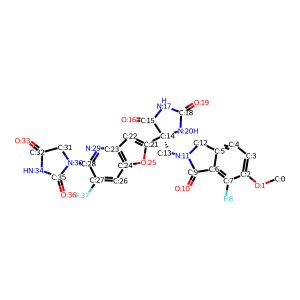

Fragments:


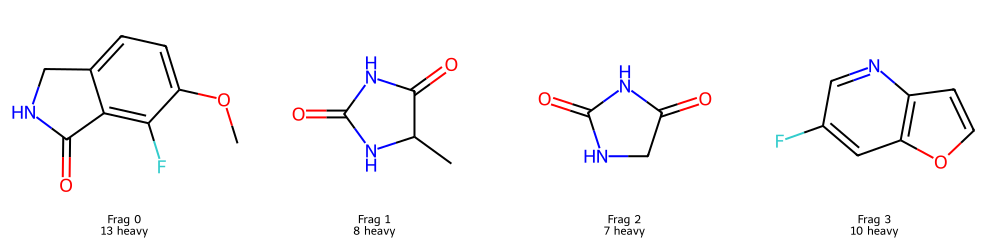

In [27]:
# Split the Reference mol into fragments
# ref_mol = Chem.MolFromMolFile('./assets/demo_files/ceyyag.mol')
ref_mol = Chem.MolFromMolFile('38_atoms_example.mol')
ref_mol = Chem.RemoveHs(ref_mol)

# Strip of Hs and align Reference to principal Inertial Frame, saving rotation and shift
ref_context, shift, rotation, _ = align_mol(ref_mol)

# Split reference into fragments
frag_sets = visualize_size_constrained_fragments(
    ref_mol,
    min_size=6,
    max_size=15,
    verbose=True,
)

# Extract the fragments based on atom ids, while keeping the absolute coordinates from Reference
extracted_frags = []

for frag_set in frag_sets:
    extracted_frags.append(extract_fragment(ref_mol, frag_set))

In [28]:
import torch
from src.mlconfgen.utils.mol_utils import prepare_masks, redefine_bonds
from src.mlconfgen.utils.standardizer import standardize_mol

N_SAMPLES = 20
CONTEXT_NORMS = {
    'mean': torch.tensor([92.1179, 413.7875, 470.5253]),
    'mad': torch.tensor([53.4742, 232.5775, 251.1813]),
}
VARIANCE = 0

# A new function to prepare concatenatable edm input for fragments

def ifm_prepare_edm_input(
    n_samples: int,
    reference_context: torch.Tensor,
    context_norms: dict,
    min_n_atoms: int,
    max_n_atoms: int,
    max_n_nodes: int,
    device: torch.device,
):

    # Create a random list of sizes between min_n_nodes and max_n_nodes of length n_samples

    nodesxsample = torch.randint(min_n_atoms, max_n_atoms + 1, (n_samples,))

    node_mask, edge_mask = prepare_masks(
        n_nodes=nodesxsample,
        max_n_nodes=max_n_nodes,
        device=device,
    )

    normed_context = (
        (reference_context - context_norms["mean"]) / context_norms["mad"]
    ).to(device)

    batch_context = normed_context.unsqueeze(0).repeat(n_samples, 1)

    batch_context = batch_context.unsqueeze(1).repeat(1, max_n_nodes, 1) * node_mask

    return (
        node_mask,
        edge_mask,
        batch_context,
    )

def predict_bonds(generator, edm_samples):
        (
            el_batch,
            dm_batch,
            b_adj_mat_batch,
            canonicalised_samples,
        ) = prepare_adj_mat_seer_input(
            mols=edm_samples,
            dimension=generator.dimension,
            device=generator.device,
        )

        adj_mat_batch = generator.adj_mat_seer(
            elements=el_batch, dist_mat=dm_batch, adj_mat=b_adj_mat_batch
        )

        adj_mat_batch = adj_mat_batch.to("cpu")

        # Append generated bonds and standardise existing samples
        optimised_conformers = []

        for i, adj_mat in enumerate(adj_mat_batch):
            f_mol = redefine_bonds(canonicalised_samples[i], adj_mat)
            std_mol = standardize_mol(mol=f_mol, optimize_geometry=True)
            if std_mol:
                optimised_conformers.append(std_mol)
            

        return optimised_conformers


# Align Fragments to their respective Principal Inertial Frames, while remembering corresponding Shifts and Rotations

frag_contexts = []
fragment_shifts = []
fragment_rotations = []
ref_frag_coords = []

edm_inputs = []

# Determine the max number of nodes
max_n_nodes = 0
for frag in extracted_frags:
    n_atoms = frag.GetNumHeavyAtoms()
    if n_atoms > max_n_nodes:
        max_n_nodes = n_atoms

# Account for variance
max_n_nodes = max_n_nodes + VARIANCE

# Prepare concatenatable edm inputs for all fragments
for frag in extracted_frags:
    n_atoms = frag.GetNumHeavyAtoms()
    con, sh, rot, coord = align_mol(frag)
    frag_contexts.append(con)
    fragment_shifts.append(sh)
    fragment_rotations.append(rot)
    ref_frag_coords.append(coord)
    min_n_atoms = n_atoms - VARIANCE
    max_n_atoms = n_atoms + VARIANCE

   
    node_mask, edge_mask, batch_context = ifm_prepare_edm_input(
            n_samples=N_SAMPLES,
            reference_context=con,
            context_norms=CONTEXT_NORMS,
            min_n_atoms=min_n_atoms,
            max_n_atoms=max_n_atoms,
            max_n_nodes = max_n_nodes,
            device="cpu",
        )
    edm_inputs.append({
        "node_mask": node_mask,
        "edge_mask": edge_mask,
        "batch_context": batch_context
    })

# Check sizes
for i, item in enumerate(edm_inputs):
    print(f"Fragment{i}")
    for key, value in item.items():
        print(f"{key}\t{value.size()}")

# concatenate edm_inputs to create merged edm input for all fragments at the same time
# First N_Samples - first Fragment, Second N_Samples - second Fragment e.t.c

total_node_mask = torch.cat([x["node_mask"] for x in edm_inputs], 0)
total_batched_context = torch.cat([x["batch_context"] for x in edm_inputs])

# Total Edge mask is a bit trickier:
helper_node_mask = total_node_mask.clone().squeeze()
batch_size = helper_node_mask.size(0)
max_n_nodes = helper_node_mask.size(1)


# Compute Total Edge Mask
total_edge_mask = helper_node_mask.unsqueeze(1) * helper_node_mask.unsqueeze(2)
diag_mask = ~torch.eye(total_edge_mask.size(1), dtype=torch.bool).unsqueeze(0)
total_edge_mask *= diag_mask
total_edge_mask = total_edge_mask.view(batch_size * max_n_nodes * max_n_nodes, 1)


print(f"Total Node Mask Size - {total_node_mask.size()}")
print(f"Total Edge Mask Size - {total_edge_mask.size()}")
print(f"Total Batched Context Size - {total_batched_context.size()}")

tensor([[21.2892, -6.1661,  2.2631],
        [-6.1661, 58.2239, -5.7128],
        [ 2.2631, -5.7128, 75.5046]])
tensor([[23.9864, -2.8301,  1.6082],
        [-2.8301, 11.0457,  2.8130],
        [ 1.6082,  2.8130, 15.7966]])
tensor([[ 7.2357, -3.6543,  1.9601],
        [-3.6543, 12.2984,  1.4153],
        [ 1.9601,  1.4153, 18.6539]])
tensor([[12.4840, -6.6755,  4.0963],
        [-6.6755, 28.6598,  2.3582],
        [ 4.0963,  2.3582, 39.5641]])
Fragment0
node_mask	torch.Size([20, 13, 1])
edge_mask	torch.Size([3380, 1])
batch_context	torch.Size([20, 13, 3])
Fragment1
node_mask	torch.Size([20, 13, 1])
edge_mask	torch.Size([3380, 1])
batch_context	torch.Size([20, 13, 3])
Fragment2
node_mask	torch.Size([20, 13, 1])
edge_mask	torch.Size([3380, 1])
batch_context	torch.Size([20, 13, 3])
Fragment3
node_mask	torch.Size([20, 13, 1])
edge_mask	torch.Size([3380, 1])
batch_context	torch.Size([20, 13, 3])
Total Node Mask Size - torch.Size([80, 13, 1])
Total Edge Mask Size - torch.Size([13520, 1])
Tot

Intitialising model on cpu
Generating Sample Fragments
X Size: torch.Size([80, 13, 3])
H Size: torch.Size([80, 13, 8])


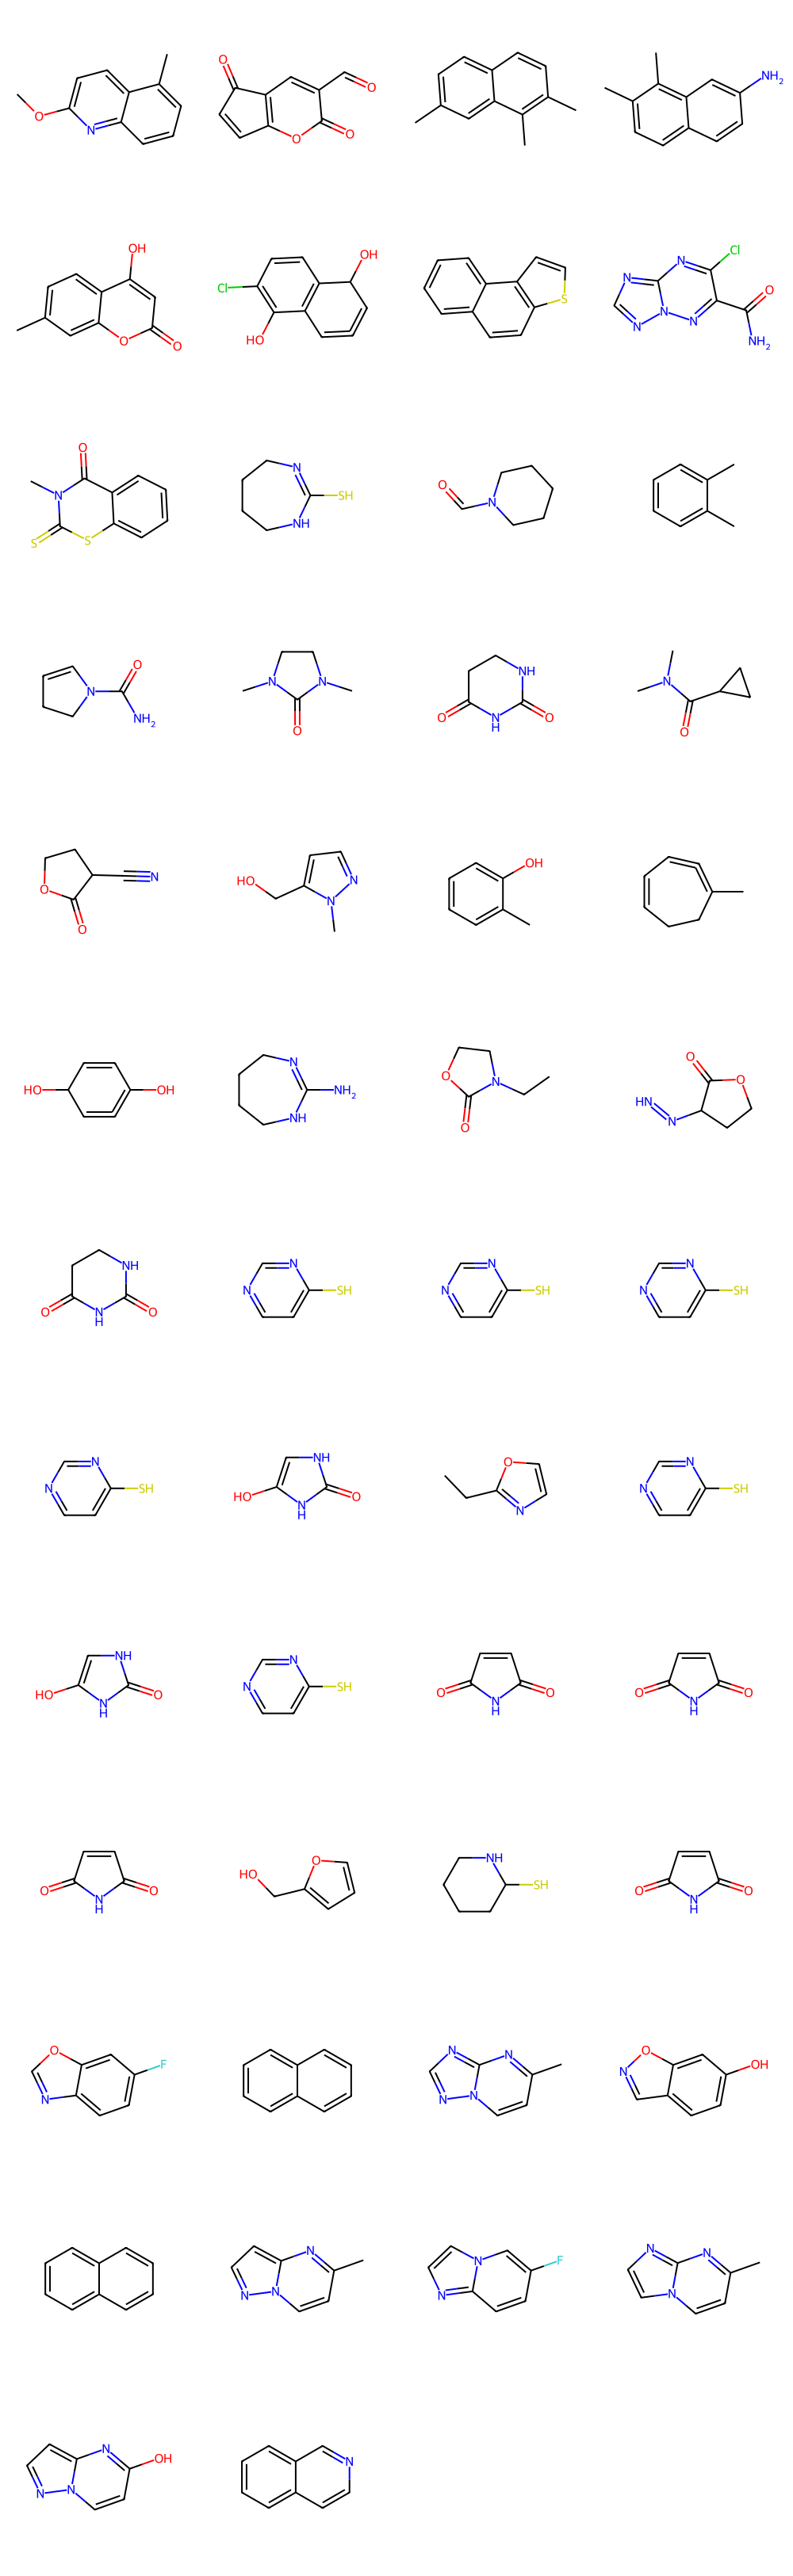

In [38]:
from rdkit import RDLogger

from src.mlconfgen import MLConformerGenerator
from src.mlconfgen.utils import samples_to_rdkit_mol, prepare_adj_mat_seer_input

RESAMPLE_STEPS = 2
# Initialise the Generator model
RDLogger.DisableLog('rdApp.*')

# if torch.cuda.is_available():
#     device = torch.device("cuda:0")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps:0")
# else:
device = torch.device("cpu")

print(f"Intitialising model on {device}")
    
generator = MLConformerGenerator(
                                 edm_weights="./licensed_edm_moi_chembl_6_39_final.pt",
                                 adj_mat_seer_weights="./adj_mat_seer_chembl_15_39.pt",
                                 device=device,
                                 diffusion_steps=50, # Light generation for debugging
                                )

# Generate samples for all fragments at the same time (N_frgaments x N Samples) samples total

total_node_mask = total_node_mask.detach().to(device)
total_edge_mask = total_edge_mask.detach().to(device)
total_batched_context = total_batched_context.detach().to(device)

print("Generating Sample Fragments")
with torch.no_grad():
    total_x, total_h = generator.generative_model(
                                                    total_node_mask,
                                                    total_edge_mask,
                                                    total_batched_context,
                                                    resample_steps=RESAMPLE_STEPS,
                                                 )

gen_mols = samples_to_rdkit_mol(
            positions=total_x, one_hot=total_h, node_mask=total_node_mask, atom_decoder=generator.atom_decoder
        )

print(f"X Size: {total_x.size()}")
print(f"H Size: {total_h.size()}")

temp_mols = predict_bonds(generator, gen_mols)
temp_mols = [Chem.MolFromSmiles(Chem.MolToSmiles(x)) for x in temp_mols]
img = Draw.MolsToGridImage(
        temp_mols,
        molsPerRow=4,
        subImgSize=(250, 250),
    )

display(img)

In [39]:
import py3Dmol
from rdkit import Chem

from src.mlconfgen.utils import inverse_coord_transform


def show_overlay_grid(
    reference_mol,
    candidate_mols,
    n_cols=3,
    width=300,
    height=300,
):

    def mol_to_block(mol):
        return Chem.MolToXYZBlock(mol)

    n_rows = (len(candidate_mols) + n_cols - 1) // n_cols

    view = py3Dmol.view(
        viewergrid=(n_rows, n_cols),
        width=width * n_cols,
        height=height * n_rows,
    )

    ref_block = mol_to_block(reference_mol)

    for i, cand in enumerate(candidate_mols):
        r = i // n_cols
        c = i % n_cols

        

        # Add reference (magenta)
        view.addModel(ref_block, "xyz", viewer=(r, c))
        view.setStyle(
            {"model": 0},
            {"stick": {"color": "magenta", "radius": 0.2}},
            viewer=(r, c),
        )

        # Add candidates

        for j, frag in enumerate(cand):
            cand_block = mol_to_block(frag)
            view.addModel(cand_block, "xyz", viewer=(r, c))
            view.setStyle(
                {"model": j + 1},
                {"stick": {"radius": 0.2}},
                viewer=(r, c),
            )

        view.zoomTo(viewer=(r, c))

    view.show()
    return None

# Split generated tensor into samples generated per fragment
x_fragments = torch.split(total_x, N_SAMPLES, dim=0)
h_fragments = torch.split(total_h, N_SAMPLES, dim=0)

# Batchify shifts and rotations
# Apply corresponding inverse coord transforms to each fragment coordinates
# Visually check the generated fragments after alignment to the frame of Reference
prepared_fragments = []
coord_for_merge = []

for i, frag_coord in enumerate(x_fragments):
    batch_shift = fragment_shifts[i].unsqueeze(0).expand(N_SAMPLES, -1)
    batch_rot = fragment_rotations[i].transpose(0,1).unsqueeze(0).expand(N_SAMPLES, 3, -1)

    # Aha, here is the problem with the IFM - the generated samples should be re-aligned after generation, prior to merge
    # Currently aligning using moi, however maybe we will need to align with shape quadrupole...
    # Probably, the key BottleNeck
    aligned_x = []
    for old_x in frag_coord:
        aligned_x.append(align_coord(ref_frag_coords[i], old_x))

    aligned_x = torch.stack(aligned_x, dim=0)
    
    new_x = inverse_coord_transform(coord=aligned_x,
                                    shift=batch_shift,
                                    rotation=batch_rot.transpose(1,2),
                                   )

    # Save prepared coordinates for Merging the fragments
    coord_for_merge.append(new_x)
    
    # Visually check inverse transform
    node_mask = edm_inputs[i]["node_mask"]
    inv_tr_frag_mols = samples_to_rdkit_mol(
            positions=new_x, one_hot=h_fragments[i], node_mask=node_mask, atom_decoder=generator.atom_decoder
        )
    prepared_fragments.append(inv_tr_frag_mols)


print("Showing Alignment of the Generated Fragments to the Reference after inverse transformation")
show_overlay_grid(ref_mol, list(zip(*prepared_fragments)))



tensor([[ 52.5082,  10.6671,   7.3418],
        [ 10.6671,  43.6975, -25.1278],
        [  7.3418, -25.1278,  58.8382]])
tensor([[ 65.2081,   7.4186,  13.3476],
        [  7.4186,  27.2022, -12.4595],
        [ 13.3476, -12.4595,  62.8517]])
tensor([[ 62.4681,  -4.8773,  14.5773],
        [ -4.8773,  62.2547, -16.3144],
        [ 14.5773, -16.3144,  29.9057]])
tensor([[55.8560, 10.9732, -1.5091],
        [10.9732, 40.0065, 24.9530],
        [-1.5091, 24.9530, 58.7271]])
tensor([[ 28.4412,  -9.9782, -12.2178],
        [ -9.9782,  70.2188, -12.2822],
        [-12.2178, -12.2822,  56.4709]])
tensor([[ 73.2469,   0.7322,   9.1271],
        [  0.7322,  28.4761, -16.1689],
        [  9.1271, -16.1689,  53.1210]])
tensor([[ 70.5492,  -9.9885, -15.4670],
        [ -9.9885,  48.6924, -13.5180],
        [-15.4670, -13.5180,  35.3286]])
tensor([[ 52.0177, -21.7106,  -4.3331],
        [-21.7106,  49.7783, -18.2445],
        [ -4.3331, -18.2445,  52.8075]])
tensor([[ 71.8705,  -3.5100,   8.5236],
 

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Merging pre-generated and reverse-transformed fragments...
torch.Size([20, 38, 11])
Merging Complete
AVERAGE SHAPE SIMILARITY - 0.5266666666666667
VALID SAMPLES - 15.0 %


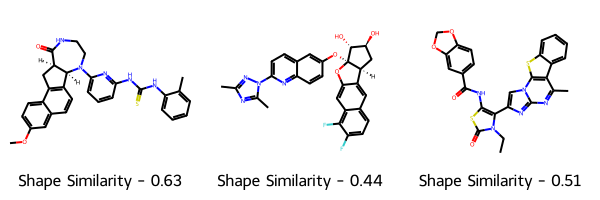

In [75]:
from src.mlconfgen.utils import prepare_edm_input
from src.mlconfgen import evaluate_samples

from rdkit import RDLogger
from torch.nn.utils.rnn import pad_sequence


RDLogger.DisableLog('rdApp.*')

# Prepare inputs to merge fragments
# Here we can have All with All or each with corresponding
# We do each with corresponding for now

# NEED TO ACCOUNT FOR corresponding NODE MASKS for fragments! TODO! or will only work with VARIANCE=0, and work poorly on large molecules
# Check/Improve the function for different variances
def concat_masked_and_pad(xs, masks, pad_extra=0, pad_to=None, pad_value=0.0):
    """
    xs:    tuple/list of tensors, each (B, N, *D)
    masks: tuple/list of masks,  each (B, N, 1) or (B, N) (bool or 0/1)

    Returns: (B, L, *D), where L depends on pad_extra / pad_to.
    """
    # (B, K, N, *D)
    X = torch.stack(xs, dim=1)

    # (B, K, N, 1) or (B, K, N)
    M = torch.stack(masks, dim=1)
    if M.dim() == X.dim():  # mask has trailing singleton like (.., 1)
        M = M.squeeze(-1)
    M = M.bool()  # (B, K, N)

    B, K, N = M.shape
    feat_shape = X.shape[3:]          # (*D)
    flat_len = K * N

    # Flatten K and N -> (B, K*N, *D)
    Xf = X.reshape(B, flat_len, *feat_shape)
    Mf = M.reshape(B, flat_len)

    # Select ragged per batch: list of (Li, *D)
    selected = [Xf[b][Mf[b]] for b in range(B)]

    # If some batch has zero selected rows, ensure correct shape for padding
    empty = X.new_zeros((0, *feat_shape))
    selected = [t if t.numel() else empty for t in selected]

    # Pad to max Li in batch -> (B, Lmax, *D)
    out = pad_sequence(selected, batch_first=True, padding_value=pad_value)

    # Decide final length
    if pad_to is not None:
        L = pad_to
    else:
        L = out.size(1) + pad_extra

    # Pad/truncate to L
    if out.size(1) < L:
        pad = out.new_full((B, L - out.size(1), *feat_shape), pad_value)
        out = torch.cat([out, pad], dim=1)
    else:
        out = out[:, :L]

    return out


# merged_x = torch.cat(coord_for_merge, dim=1)
# merged_h = torch.cat(h_fragments, dim=1)
# merged_node_mask = torch.cat([x["node_mask"] for x in edm_inputs], 1)

node_masks = [x["node_mask"] for x in edm_inputs]
merged_x = concat_masked_and_pad(coord_for_merge, node_masks, pad_to=38)
merged_h = concat_masked_and_pad(h_fragments, node_masks, pad_to=38)
merged_node_mask = concat_masked_and_pad(node_masks, node_masks, pad_to=38)

z_seed = torch.cat([merged_x, merged_h], dim=2)


#  Merged Edge mask 
helper_node_mask = merged_node_mask.clone().squeeze()
batch_size = helper_node_mask.size(0)
max_n_nodes = helper_node_mask.size(1)


# Compute Merged Edge Mask
merged_edge_mask = helper_node_mask.unsqueeze(1) * helper_node_mask.unsqueeze(2)
diag_mask = ~torch.eye(merged_edge_mask.size(1), dtype=torch.bool).unsqueeze(0)
merged_edge_mask *= diag_mask
merged_edge_mask = merged_edge_mask.view(batch_size * max_n_nodes * max_n_nodes, 1)

# Batch the context for Reference

_, _, batch_ref_context = prepare_edm_input(
                                            n_samples=N_SAMPLES,
                                            reference_context=ref_context,
                                            context_norms=CONTEXT_NORMS,
                                            min_n_nodes=max_n_nodes,
                                            max_n_nodes=max_n_nodes,
                                            device=device,
                                            )

# And Merge the pre-generated Fragments

print("Merging pre-generated and reverse-transformed fragments...")
print(z_seed.size())

with torch.no_grad():
    final_x, final_h = generator.generative_model.ifm_merge_fragments(
                                                    node_mask=merged_node_mask,
                                                    edge_mask=merged_edge_mask,
                                                    context=batch_ref_context,
                                                    z_seed=z_seed,
                                                    diffusion_level=10,
                                                    resample_steps=0,
                                                 )

print("Merging Complete")

final_mols = samples_to_rdkit_mol(
            positions=final_x, one_hot=final_h, node_mask=merged_node_mask, atom_decoder=generator.atom_decoder
        )

final_mols = predict_bonds(generator, final_mols)

_, std_samples = evaluate_samples(ref_mol, final_mols)

# Display results
mols = []
legends = []
average_shape_similarity = 0
for sample in std_samples:
    mol = Chem.MolFromMolBlock(sample['mol_block'])
    mol = Chem.MolFromSmiles(Chem.MolToSmiles(mol))
    mol.SetProp("Shape_Tanimoto", str(sample['shape_tanimoto']))
    mols.append(mol)
    legends.append(f"Shape Similarity - {round(sample['shape_tanimoto'], 2)}")
    average_shape_similarity += round(sample['shape_tanimoto'], 2)

average_shape_similarity = average_shape_similarity / len(std_samples)
print(f"AVERAGE SHAPE SIMILARITY - {average_shape_similarity}")
print(f"VALID SAMPLES - {round(len(std_samples) / N_SAMPLES, 2) * 100} %")
    
Draw.MolsToGridImage(mols, legends=legends)